In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go


import pandas as pd
df = pd.read_csv('messy_employee_data.csv')
df.head()

,EmployeeID,Name,Age,Salary,Department,JoinDate,City,PerformanceScore,Email
0,52,John Larsen,50,999999.00,IT,NaN,Houston,9.3,john.larsen@company.com
1,4,WEI ALI,27,70806.93,Operations,2022-11-09,Chicago,6.5,wei.ali@company.com
2,41,Zara Tanaka,56,115325.63,sales,not available,Seattle,5.0,NaN
3,32,Ingrid Chen,29,64473.18,Marketing,not available,Boston,1.6,ingrid.chen@company.com
4,71,Sofia Fernandez,58,75345.48,Finance,not available,Boston,7.2,sofia.fernandez@company.com


In [72]:
df.info()  #gives us quick overall summary of the data frame

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   EmployeeID        158 non-null    int64  
 1   Name              158 non-null    str    
 2   Age               158 non-null    int64  
 3   Salary            154 non-null    float64
 4   Department        158 non-null    str    
 5   JoinDate          134 non-null    str    
 6   City              140 non-null    str    
 7   PerformanceScore  138 non-null    float64
 8   Email             142 non-null    str    
dtypes: float64(2), int64(2), str(5)
memory usage: 11.2 KB


In [73]:
df.describe()  #gives us a statistical summary of the data frame

,EmployeeID,Age,Salary,PerformanceScore
count,158.000000,158.000000,154.000000,138.000000
mean,75.367089,39.791139,93624.621169,155.820290
std,43.549277,24.931512,152263.340033,358.533186
min,1.000000,-5.000000,-20000.000000,-1.000000
25%,38.250000,27.000000,45881.382500,2.675000
50%,75.500000,37.000000,73784.630000,5.200000
75%,112.750000,50.000000,101838.867500,8.450000
max,150.000000,150.000000,999999.000000,999.000000


In [74]:
df.isna().sum()  #gives us the number of missing values in each column

EmployeeID           0
Name                 0
Age                  0
Salary               4
Department           0
JoinDate            24
City                18
PerformanceScore    20
Email               16
dtype: int64

In [75]:
df["Salary"] = df["Salary"].fillna(df["Salary"].median()) #fill missing salary values with the median salary

In [76]:
df["City"] = df["City"].fillna("Unknown") #fill missing city values with "Unknown"

In [77]:
df["PerformanceScore"] = df["PerformanceScore"].fillna(
    df["PerformanceScore"].median() #fillna missing performance score values with the median performance score
)

In [78]:
df["Email"] = df["Email"].fillna("Unknown") #fill missing email values with "Unknown"

In [79]:
df = df.dropna(subset=["JoinDate"]) #dropna rows where JoinDate is missing

In [80]:
df.isna().sum() #gives us the number of missing values in each column

EmployeeID          0
Name                0
Age                 0
Salary              0
Department          0
JoinDate            0
City                0
PerformanceScore    0
Email               0
dtype: int64

In [81]:
df.dropna(inplace=True) #dropna rows where any column is missing

In [82]:
df.duplicated().sum()

np.int64(6)

In [83]:
df[df.duplicated()]

,EmployeeID,Name,Age,Salary,Department,JoinDate,City,PerformanceScore,Email
33,15,Emma Hussain,21,113386.63,sales,2021.06.10,Phoenix,999.0,emma.hussain@company.com
70,142,Mei Kim,31,45233.91,Marketing,2019-01-26,New York,7.9,mei.kim@company.com
88,99,Priya Patel,40,119021.04,Sales,2019-04-19,CHICAGO,3.5,priya.patel@company.com
112,57,Sam Patel,27,77335.60,IT,2021.06.10,CHICAGO,6.6,sam.patel@company.com
124,17,Zara Sharma,60,89163.58,HR,03/15/2020,new york,5.1,Unknown
155,132,Wei Wang,23,46198.32,Operations,2019-07-24,Miami,2.2,wei.wang@company.com


In [84]:
df.drop_duplicates(inplace=True)

In [85]:
df.dtypes

EmployeeID            int64
Name                    str
Age                   int64
Salary              float64
Department              str
JoinDate                str
City                    str
PerformanceScore    float64
Email                   str
dtype: object

In [86]:
df["JoinDate"] = df["JoinDate"].replace("not available", np.nan)

In [87]:
df["JoinDate"] = pd.to_datetime(df["JoinDate"], format="mixed")

In [88]:
df.dtypes


EmployeeID                   int64
Name                           str
Age                          int64
Salary                     float64
Department                     str
JoinDate            datetime64[us]
City                           str
PerformanceScore           float64
Email                          str
dtype: object

In [89]:
df["JoinDate"].unique()

<DatetimeArray>
['2022-11-09 00:00:00',                 'NaT', '2020-03-15 00:00:00',
 '2021-06-10 00:00:00', '2019-02-15 00:00:00', '2019-06-12 00:00:00',
 '2019-01-26 00:00:00', '2022-05-20 00:00:00', '2022-11-07 00:00:00',
 '2019-05-17 00:00:00', '2019-08-11 00:00:00', '2019-04-19 00:00:00',
 '2019-05-15 00:00:00', '2022-12-28 00:00:00', '2022-04-24 00:00:00',
 '2022-03-22 00:00:00', '2022-11-12 00:00:00', '2019-05-11 00:00:00',
 '2019-07-20 00:00:00', '2019-08-17 00:00:00', '2022-07-22 00:00:00',
 '2019-05-19 00:00:00', '2019-08-16 00:00:00', '2019-05-12 00:00:00',
 '2019-05-27 00:00:00', '2019-09-21 00:00:00', '2019-07-24 00:00:00',
 '2019-04-14 00:00:00', '2022-02-17 00:00:00', '2019-01-23 00:00:00',
 '2019-02-26 00:00:00', '2022-10-07 00:00:00', '2022-05-02 00:00:00',
 '2022-10-20 00:00:00', '2019-01-13 00:00:00', '2019-04-15 00:00:00']
Length: 36, dtype: datetime64[us]

In [90]:
df["Department"].value_counts()

Department
  Marketing    22
Operations     17
Marketing      15
IT             14
IT             13
sales          12
HR             12
Sales          12
Finance        11
Name: count, dtype: int64

In [91]:
df["City"].value_counts()

City
CHICAGO     19
Chicago     15
Unknown     15
Seattle     14
Phoenix     13
Houston     12
new york    12
Miami       11
Boston      10
New York     7
Name: count, dtype: int64

In [92]:
df[df["City"].str.contains("chicago", case=False, na=False)]["City"].unique()

<StringArray>
['Chicago', 'CHICAGO']
Length: 2, dtype: str

In [93]:
df["Age"].describe()

count    128.00000
mean      41.21875
std       26.38627
min       -5.00000
25%       27.00000
50%       38.00000
75%       50.00000
max      150.00000
Name: Age, dtype: float64

In [94]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

print(Q1)
print(Q3)
print(IQR)

27.0
50.0
23.0


In [95]:
Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR


In [96]:
outliers = df[(df["Age"] < Lower) | (df["Age"] > Upper)]

In [97]:
outliers

,EmployeeID,Name,Age,Salary,Department,JoinDate,City,PerformanceScore,Email
17,42,Aisha Hussain,150,63211.84,Marketing,2021-06-10,new york,3.3,aisha.hussain@company.com
106,2,Ingrid Brown,150,55037.16,sales,2021-06-10,Chicago,1.8,ingrid.brown@company.com
108,47,Emma Smith,150,72292.12,Finance,2020-03-15,new york,-1.0,emma.smith@company.com
110,72,NOAH CHEN,150,43350.04,Marketing,2021-06-10,Seattle,5.5,Unknown
143,67,Noah Rossi,150,96804.21,Marketing,2022-05-02,CHICAGO,3.0,noah.rossi@company.com


In [98]:
df.loc[(df["Age"] < Lower) | (df["Age"] > Upper), "Age"] = np.nan

In [99]:

df["Age"] = df["Age"].fillna(df["Age"].median())

In [100]:
df["Age"].describe()

count    128.000000
mean      36.843750
std       14.542058
min       -5.000000
25%       27.000000
50%       38.000000
75%       48.000000
max       60.000000
Name: Age, dtype: float64

In [101]:
df[df["Age"] <= 0]

,EmployeeID,Name,Age,Salary,Department,JoinDate,City,PerformanceScore,Email
10,16,Priya Patel,-5.0,72910.97,Marketing,2019-02-15,Phoenix,999.0,priya.patel@company.com
25,85,Olga Chen,0.0,0.00,Marketing,2020-03-15,CHICAGO,5.2,olga.chen@company.com
81,60,Emma Johnson,-5.0,108375.56,IT,NaT,new york,7.0,emma.johnson@company.com
87,53,Mei Khan,0.0,101938.24,Marketing,2020-03-15,Chicago,5.2,mei.khan@company.com
113,129,Ingrid Muller,0.0,108582.16,IT,2019-09-21,New York,5.2,ingrid.muller@company.com
121,29,Wei Kim,0.0,47499.17,sales,2019-04-14,Chicago,8.0,wei.kim@company.com
128,38,Aisha Khan,0.0,102497.52,Marketing,2022-02-17,CHICAGO,1.1,aisha.khan@company.com


In [102]:
df.loc[df["Age"] <= 0, "Age"] = np.nan

In [103]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [104]:
df["Age"].describe()

count    128.000000
mean      39.000000
std       11.217955
min       21.000000
25%       28.000000
50%       38.000000
75%       48.000000
max       60.000000
Name: Age, dtype: float64

In [105]:
df["PerformanceScore"].describe()

count    128.000000
mean     128.928125
std      330.159087
min       -1.000000
25%        3.075000
50%        5.200000
75%        7.900000
max      999.000000
Name: PerformanceScore, dtype: float64

In [106]:
df[df["PerformanceScore"].isin([-1, 999])]

,EmployeeID,Name,Age,Salary,Department,JoinDate,City,PerformanceScore,Email
10,16,Priya Patel,38.0,72910.97,Marketing,2019-02-15,Phoenix,999.0,priya.patel@company.com
14,102,Priya Chen,46.0,102098.64,IT,2020-03-15,CHICAGO,999.0,Unknown
20,90,Diego Sharma,42.0,83752.18,IT,2021-06-10,Phoenix,999.0,diego.sharma@company.com
24,15,Emma Hussain,21.0,113386.63,sales,2021-06-10,Phoenix,999.0,emma.hussain@company.com
30,5,Aisha Johnson,50.0,119057.10,Sales,2021-06-10,Chicago,999.0,aisha.johnson@company.com
35,93,Aisha Kim,43.0,34793.12,sales,2021-06-10,Chicago,-1.0,aisha.kim@company.com
37,9,Diego Novak,33.0,73784.63,Operations,2021-06-10,Phoenix,999.0,diego.novak@company.com
49,58,Ravi Larsen,45.0,73784.63,Marketing,2019-04-19,Boston,-1.0,ravi.larsen@company.com
53,59,Fatima Kim,31.0,111308.17,Sales,2020-03-15,Phoenix,999.0,fatima.kim@company.com
54,88,Carlos Rossi,40.0,41605.65,Marketing,2022-03-22,Miami,-1.0,carlos.rossi@company.com


In [107]:
df.loc[df["PerformanceScore"].isin([-1, 999]), "PerformanceScore"] = np.nan

In [108]:
df["PerformanceScore"] = df["PerformanceScore"].fillna(
    df["PerformanceScore"].median()
)

In [109]:
df["PerformanceScore"].describe()

count    128.000000
mean       5.139063
std        2.143448
min        1.100000
25%        3.750000
50%        5.200000
75%        5.725000
max       10.000000
Name: PerformanceScore, dtype: float64

In [110]:
df["Salary"].describe()

count       128.000000
mean      85545.917187
std      120260.051685
min      -20000.000000
25%       47434.050000
50%       73784.630000
75%      101640.122500
max      999999.000000
Name: Salary, dtype: float64

In [111]:
df[df["Salary"] < 0]

,EmployeeID,Name,Age,Salary,Department,JoinDate,City,PerformanceScore,Email
97,104,Ahmed Larsen,28.0,-20000.0,Finance,2019-08-16,Seattle,2.6,ahmed.larsen@company.com
99,81,Grace Petrov,28.0,-20000.0,IT,2019-06-12,Phoenix,4.9,grace.petrov@company.com
140,130,Ingrid Garcia,31.0,-20000.0,IT,2019-02-26,Seattle,2.2,ingrid.garcia@company.com


In [112]:
df[df["Salary"] > 200000]

,EmployeeID,Name,Age,Salary,Department,JoinDate,City,PerformanceScore,Email
117,65,Ahmed Smith,37.0,999999.0,sales,NaT,New York,5.2,ahmed.smith@company.com
127,21,Ingrid Smith,28.0,999999.0,Marketing,2021-06-10,CHICAGO,9.1,ingrid.smith@company.com


In [113]:
df.loc[(df["Salary"] < 0) | (df["Salary"] > 200000), "Salary"] = np.nan

In [114]:
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

In [115]:
df["Salary"].describe()

count       128.000000
mean      73271.894922
std       29732.997184
min           0.000000
25%       50605.955000
50%       73784.630000
75%      100675.705000
max      119057.100000
Name: Salary, dtype: float64

In [116]:
df[df["Salary"] <= 0]

,EmployeeID,Name,Age,Salary,Department,JoinDate,City,PerformanceScore,Email
25,85,Olga Chen,38.0,0.0,Marketing,2020-03-15,CHICAGO,5.2,olga.chen@company.com
27,141,Sam Brown,39.0,0.0,HR,2021-06-10,new york,7.9,sam.brown@company.com
111,113,Aisha Muller,58.0,0.0,IT,2019-05-27,Boston,2.2,aisha.muller@company.com
123,79,Sam Wang,54.0,0.0,Sales,2020-03-15,new york,3.6,Unknown
153,22,Liam Ali,27.0,0.0,IT,2019-04-15,Houston,7.6,liam.ali@company.com


In [117]:
df.loc[df["Salary"] <= 0, "Salary"] = np.nan

In [118]:
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

In [119]:
df["Salary"].describe()

count       128.000000
mean      76154.107031
std       25774.405791
min       30466.330000
25%       54559.697500
50%       73784.630000
75%      100675.705000
max      119057.100000
Name: Salary, dtype: float64

In [120]:
df["EmployeeID"].describe()

count    128.000000
mean      74.062500
std       43.745101
min        1.000000
25%       37.500000
50%       72.500000
75%      111.250000
max      150.000000
Name: EmployeeID, dtype: float64

In [121]:
df["Department"].value_counts()

Department
  Marketing    22
Operations     17
Marketing      15
IT             14
IT             13
sales          12
HR             12
Sales          12
Finance        11
Name: count, dtype: int64

In [122]:
df["City"].value_counts()

City
CHICAGO     19
Chicago     15
Unknown     15
Seattle     14
Phoenix     13
Houston     12
new york    12
Miami       11
Boston      10
New York     7
Name: count, dtype: int64

In [123]:
df["Department"] = df["Department"].str.title()

In [124]:
df["Department"].value_counts()

Department
Sales          24
  Marketing    22
Operations     17
Marketing      15
It             14
It             13
Hr             12
Finance        11
Name: count, dtype: int64

In [125]:
df["Department"] = df["Department"].str.strip().str.title()

df["Department"] = df["Department"].replace({
    "It": "IT",
    "Hr": "HR"
})

In [126]:
df["Department"].value_counts()

Department
Marketing     37
IT            27
Sales         24
Operations    17
HR            12
Finance       11
Name: count, dtype: int64

# VISULIZATION OF THE DATA TO MAKE BETTER DECISION

# EMPLOYEES DISTRIBUTION

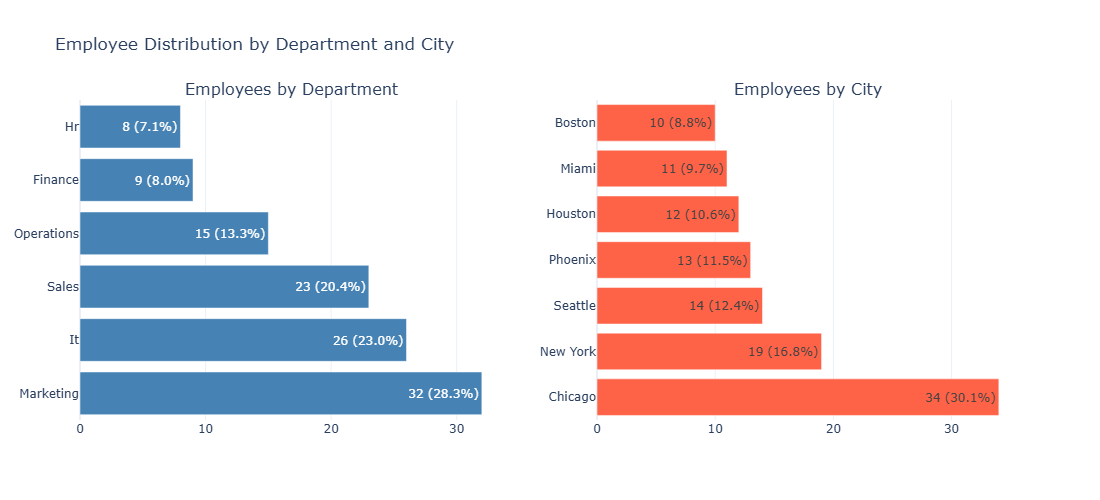

In [127]:
import plotly.subplots as sp
import plotly.graph_objects as go
import pandas as pd

# --- Step 1: Clean Data ---
df['Department'] = df['Department'].str.title()
df['City'] = df['City'].str.title()

# Remove rows where City is missing or 'Unknown'
df = df[df['City'].notna() & (df['City'] != 'Unknown')]

# --- Step 2: Count Employees ---
dept_counts = df['Department'].value_counts().sort_values(ascending=False)
city_counts = df['City'].value_counts().sort_values(ascending=False)

# --- Step 3: Percentages ---
dept_percent = (dept_counts / dept_counts.sum() * 100).round(1)
city_percent = (city_counts / city_counts.sum() * 100).round(1)

# --- Step 4: Create Subplots ---
fig = sp.make_subplots(rows=1, cols=2, subplot_titles=("Employees by Department", "Employees by City"))

# --- Department Bar Chart ---
fig.add_trace(go.Bar(
    y=dept_counts.index,
    x=dept_counts.values,
    orientation='h',
    marker_color='steelblue',
    text=[f"{count} ({pct}%)" for count, pct in zip(dept_counts.values, dept_percent)],
    textposition='auto',
    hovertemplate="Department: %{y}<br>Employees: %{x}<br>Percentage: %{text}<extra></extra>"
), row=1, col=1)

# --- City Bar Chart ---
fig.add_trace(go.Bar(
    y=city_counts.index,
    x=city_counts.values,
    orientation='h',
    marker_color='tomato',
    text=[f"{count} ({pct}%)" for count, pct in zip(city_counts.values, city_percent)],
    textposition='auto',
    hovertemplate="City: %{y}<br>Employees: %{x}<br>Percentage: %{text}<extra></extra>"
), row=1, col=2)

# --- Layout ---
fig.update_layout(
    title="Employee Distribution by Department and City",
    template="plotly_white",
    width=1100,
    height=500,
    showlegend=False
)

fig.show(renderer="png")


# SALARY ANALYSIS

In [128]:
avg_salary = df.groupby("Department")["Salary"].mean()
avg_salary

Department
Finance       73677.563333
Hr            79890.911250
It            77808.445385
Marketing     72039.450313
Operations    75272.684667
Sales         86326.696522
Name: Salary, dtype: float64

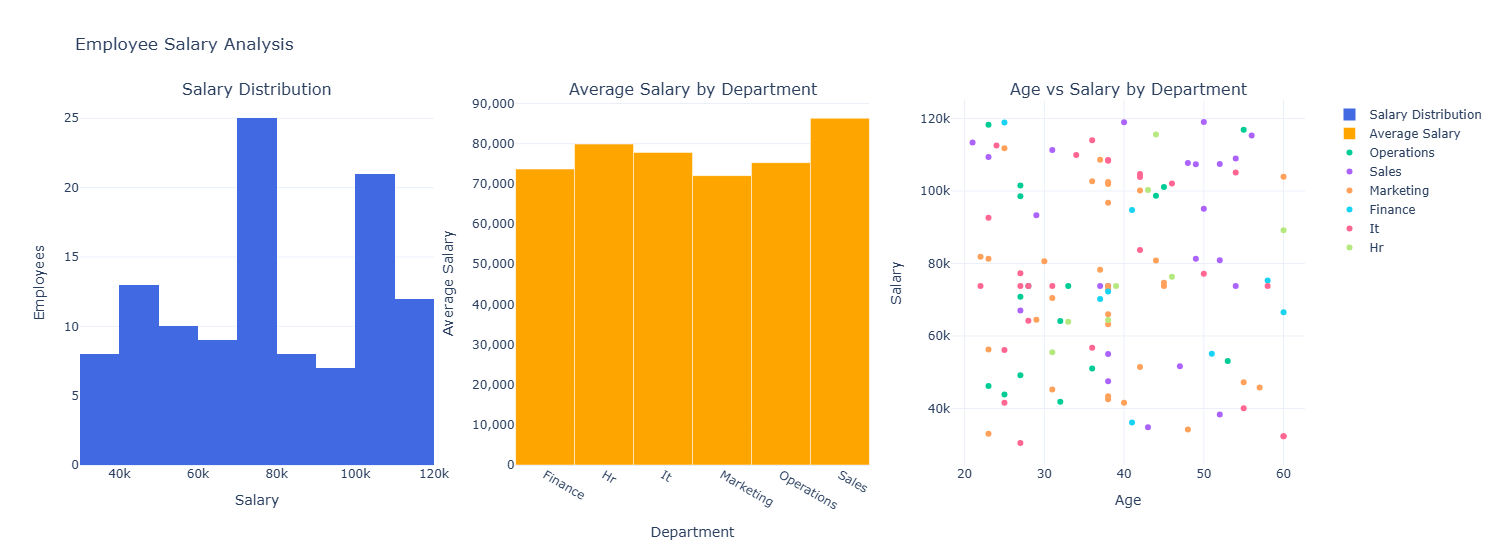

In [129]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

avg_salary = df.groupby("Department")["Salary"].mean()

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=(
        "Salary Distribution",
        "Average Salary by Department",
        "Age vs Salary by Department"
    )
)

# 1️⃣ Salary Distribution
fig.add_trace(
    go.Histogram(
        x=df["Salary"],
        nbinsx=10,
        marker_color="royalblue",
        hovertemplate="Salary: %{x}<br>Employees: %{y}<extra></extra>"
    ),
    row=1,
    col=1
)

# 2️⃣ Average Salary by Department
fig.add_trace(
    go.Bar(
        x=avg_salary.index,
        y=avg_salary.values,
        marker_color="orange",
        hovertemplate="Department: %{x}<br>Average Salary: %{y:.2f}<extra></extra>"
    ),
    row=1,
    col=2
)

# 3️⃣ Age vs Salary by Department
for department in df["Department"].unique():

    data = df[df["Department"] == department]

    fig.add_trace(
        go.Scatter(
            x=data["Age"],
            y=data["Salary"],
            mode="markers",
            name=department,
            text=data["Name"],
            hovertemplate=(
                "Name: %{text}<br>"
                "Age: %{x}<br>"
                "Salary: %{y:.2f}<extra></extra>"
            )
        ),
        row=1,
        col=3
    )

fig.update_layout(
    title="Employee Salary Analysis",
    width=1500,
    height=550,
    template="plotly_white"
)

fig.update_xaxes(title_text="Salary", row=1, col=1)
fig.update_yaxes(title_text="Employees", row=1, col=1)

fig.update_xaxes(title_text="Department", row=1, col=2)
fig.update_yaxes(title_text="Average Salary", row=1, col=2)

fig.update_xaxes(title_text="Age", row=1, col=3)
fig.update_yaxes(title_text="Salary", row=1, col=3)
fig.update_yaxes(tickformat=",", title_text="Average Salary", row=1, col=2)
# Replace default trace names
fig.data[0].name = "Salary Distribution"
fig.data[1].name = "Average Salary"

fig.show(renderer="png")

# Employee Characteristics

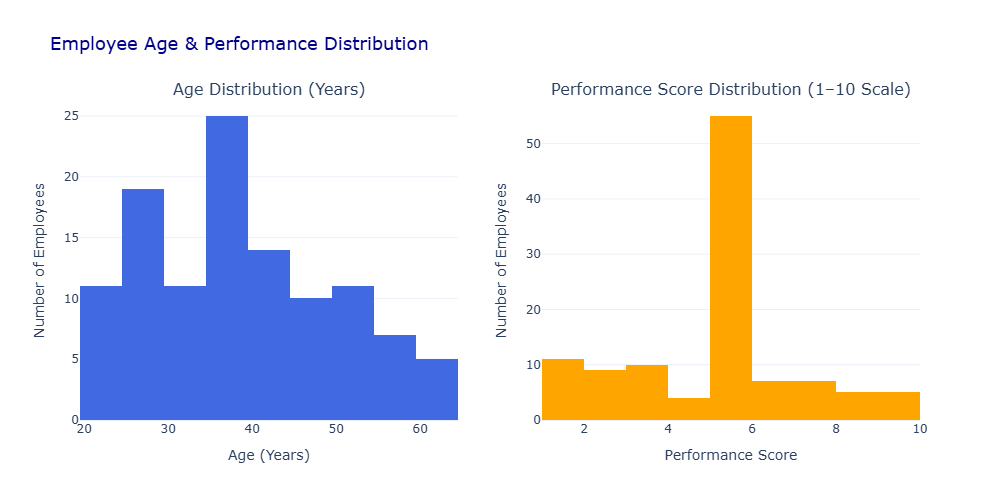

In [130]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Create Subplots ---
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Age Distribution (Years)", "Performance Score Distribution (1–10 Scale)")
)

# --- Age Distribution ---
fig.add_trace(go.Histogram(
    x=df['Age'],
    nbinsx=8,
    marker_color='royalblue',
    name='Age Distribution',
    hovertemplate="Age: %{x}<br>Employees: %{y}<extra></extra>"
), row=1, col=1)

# --- Performance Score Distribution ---
fig.add_trace(go.Histogram(
    x=df['PerformanceScore'],
    nbinsx=10,
    marker_color='orange',
    name='Performance Score Distribution',
    hovertemplate="Score: %{x}<br>Employees: %{y}<extra></extra>"
), row=1, col=2)

# --- Layout Customization ---
fig.update_layout(
    title="Employee Age & Performance Distribution",
    template="plotly_white",
    width=1000,
    height=500,
    showlegend=False,
    title_font_size=18,
    title_font_color='darkblue'
)

# --- Axis Titles ---
fig.update_xaxes(title_text="Age (Years)", row=1, col=1)
fig.update_yaxes(title_text="Number of Employees", row=1, col=1)
fig.update_xaxes(title_text="Performance Score", row=1, col=2)
fig.update_yaxes(title_text="Number of Employees", row=1, col=2)

fig.show(renderer="png")


# Relationships

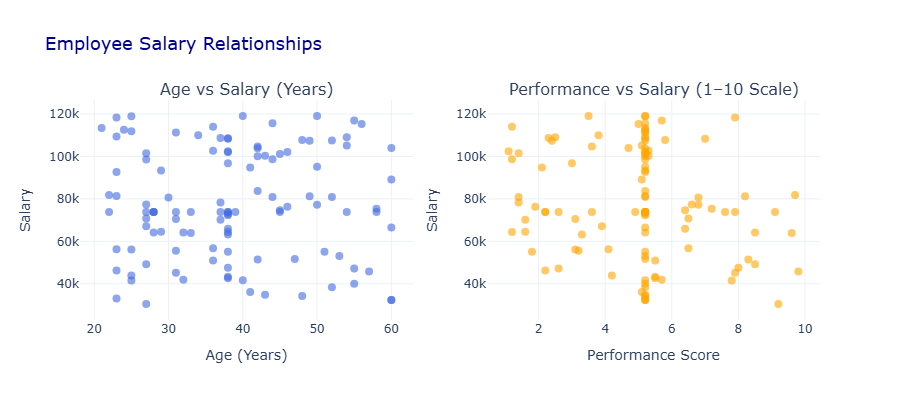

In [131]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Create Subplots ---
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Age vs Salary (Years)", "Performance vs Salary (1–10 Scale)")
)

# --- Age vs Salary ---
fig.add_trace(go.Scatter(
    x=df['Age'],
    y=df['Salary'],
    mode='markers',
    marker=dict(color='royalblue', size=8, opacity=0.6),
    name='Age vs Salary',
    hovertemplate="Age: %{x}<br>Salary: ₹%{y:,}<extra></extra>"
), row=1, col=1)

# --- Performance vs Salary ---
fig.add_trace(go.Scatter(
    x=df['PerformanceScore'],
    y=df['Salary'],
    mode='markers',
    marker=dict(color='orange', size=8, opacity=0.6),
    name='Performance vs Salary',
    hovertemplate="Performance Score: %{x}<br>Salary: ₹%{y:,}<extra></extra>"
), row=1, col=2)

# --- Layout Customization ---
fig.update_layout(
    title="Employee Salary Relationships",
    template="plotly_white",
    width=900,
    height=400,
    title_font_size=18,
    title_font_color='darkblue',
    showlegend=False
)

# --- Axis Titles ---
fig.update_xaxes(title_text="Age (Years)", row=1, col=1)
fig.update_yaxes(title_text="Salary", row=1, col=1)
fig.update_xaxes(title_text="Performance Score", row=1, col=2)
fig.update_yaxes(title_text="Salary", row=1, col=2)

fig.show(renderer="png")


# JOINING TIME TREND

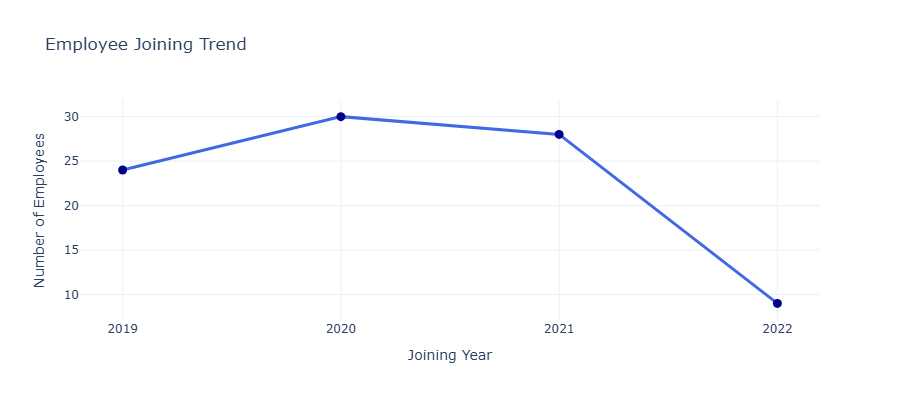

In [132]:
import plotly.graph_objects as go

# Extract joining year
df["JoinYear"] = df["JoinDate"].dt.year

joining_trend = df["JoinYear"].value_counts().sort_index()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=joining_trend.index,
    y=joining_trend.values,
    mode="lines+markers",
    name="Employees",
    line=dict(color="royalblue", width=3),
    marker=dict(color="darkblue", size=9),
    hovertemplate="Year: %{x}<br>Employees: %{y}<extra></extra>"
))

fig.update_layout(
    title="Employee Joining Trend",
    xaxis=dict(title="Joining Year", dtick=1),
    yaxis=dict(title="Number of Employees", tickformat=",d"),
    template="plotly_white",
    width=900,
    height=400
)

fig.show(renderer="png")


# CORRELATION

In [133]:
correlation = df[["Age", "Salary", "PerformanceScore"]].corr()

correlation

,Age,Salary,PerformanceScore
Age,1.000000,0.001636,-0.089004
Salary,0.001636,1.000000,-0.195305
PerformanceScore,-0.089004,-0.195305,1.000000


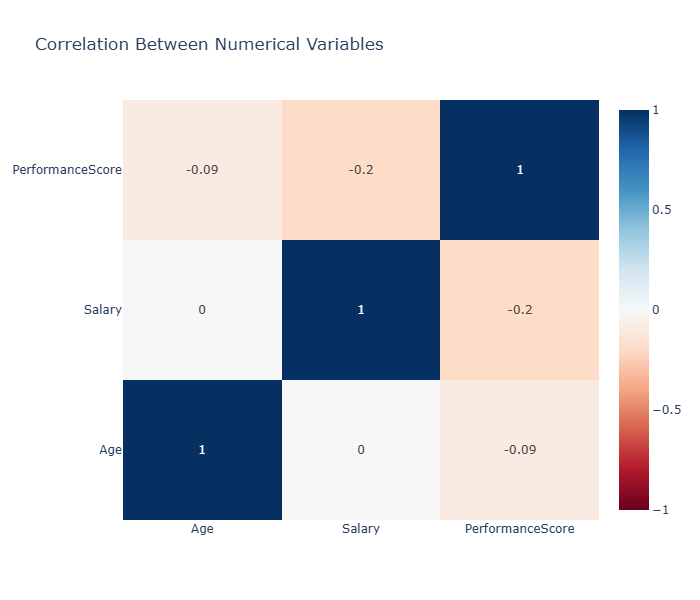

In [134]:
fig = go.Figure(
    data=go.Heatmap(
        z=correlation.values,
        x=correlation.columns,
        y=correlation.columns,
        colorscale="RdBu",
        zmin=-1,
        zmax=1,
        text=correlation.round(2).values,
        texttemplate="%{text}",
        hovertemplate=(
            "%{y} vs %{x}<br>"
            "Correlation: %{z:.2f}<extra></extra>"
        )
    )
)

fig.update_layout(
    title="Correlation Between Numerical Variables",
    width=700,
    height=600,
    template="plotly_white"
)

fig.show(renderer="png")

# 💡 Key Insights
# 👥 Workforce Distribution

# Marketing (28.3%) and Chicago (30.1%) have the largest share of employees, showing that the workforce is concentrated in one department and city.

# 💰 Salary Distribution

# Most employees earn between ₹70,000–₹90,000, with relatively few extreme salaries.

# 🏢 Department Salary

# Sales has the highest average salary, while HR and Finance have lower average salaries.

# 📊 Age & Salary

# Age and salary have almost no correlation, indicating that salary is not strongly dependent on age.

# ⭐ Performance & Salary

# Performance has a weak negative relationship with salary, meaning higher salary does not necessarily correspond to higher performance scores.

# 📅 Hiring Trend

# Employee hiring peaked in 2020, followed by a noticeable decline in 2022.

# 👤 Age Distribution

# Most employees are between 35–40 years old, while employees above 55 are relatively fewer.